In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Load base CSV
clv_df = pd.read_csv('../data/preprocessed/customers_with_RFM_clustersts.csv', encoding='ascii')

print(clv_df.head())

     ID Education   Income  Recency  MntWines  MntFruits  MntMeatProducts  \
0  5524  Graduate  58138.0       58  6.455199   4.488636         6.304449   
1  2174  Graduate  46344.0       38  2.484907   0.693147         1.945910   
2  4141  Graduate  71613.0       26  6.056784   3.912023         4.852030   
3  6182  Graduate  26646.0       26  2.484907   1.609438         3.044522   
4  5324       PhD  58293.0       94  5.159055   3.784190         4.779123   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  Age  \
0         5.153292          4.488636      4.488636  ...   69   
1         1.098612          0.693147      1.945910  ...   72   
2         4.718499          3.091042      3.761200  ...   61   
3         2.397895          1.386294      1.791759  ...   42   
4         3.850148          3.332205      2.772589  ...   45   

   Customer_Tenure_Days  Total_Spending  Total_Purchases  \
0                  4928       31.378848               25   
1                  4378        8

In [7]:
# Define CLV target and features
clv_target_col = 'Total_Spending'
X_clv = clv_df.drop(columns=[clv_target_col, 'Segment'])
y_clv = clv_df[clv_target_col]

categorical_cols_clv = X_clv.select_dtypes(include=['object']).columns.tolist()
numeric_cols_clv = X_clv.select_dtypes(exclude=['object']).columns.tolist()

preprocess_clv = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_clv),
        ('num', StandardScaler(), numeric_cols_clv)
    ]
)

reg = RandomForestRegressor(n_estimators=200, random_state=42)

clv_model = Pipeline(steps=[('preprocess', preprocess_clv), ('reg', reg)])

cv_scores = cross_val_score(clv_model, X_clv, y_clv, cv=5, scoring='r2')

print(f"Cross-Validation R2 Scores: {cv_scores}")
print(f"Mean Cross-Validation R2 Score: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of Cross-Validation R2: {np.std(cv_scores):.4f}")

X_train, X_test, y_train, y_test = train_test_split(X_clv, y_clv, test_size=0.25, random_state=42)

clv_model.fit(X_train, y_train)

y_pred = clv_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R2 Score: {r2}")
print(f"MAE: {mae}")

C:\Users\Sara\AppData\Local\Temp\ipykernel_20936\1704645269.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_clv = X_clv.select_dtypes(include=['object']).columns.tolist()


Cross-Validation R2 Scores: [0.9874043  0.9863603  0.98767936 0.98651992 0.98885307]
Mean Cross-Validation R2 Score: 0.9874
Standard Deviation of Cross-Validation R2: 0.0009
R2 Score: 0.986963299564615
MAE: 0.6561319874454209


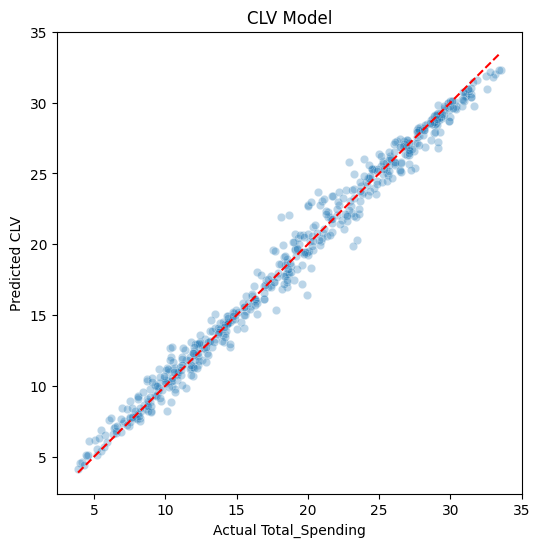

In [8]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.xlabel('Actual Total_Spending')
plt.ylabel('Predicted CLV')
plt.title('CLV Model')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

The model has an R2 of 0.99 which means it is correctly capturing customer value.

The MAE is 0.64 which is a small error for the scaled total spending data.

With this CLV model, we can now predict CLV for all customers, including new customers, and combine this with their cluster/segment to target the loyal and high-CLV customers with larger marketing budget, better deals and discounts, and focus retention efforts on these customers.

In [9]:
# Predict CLV for entire dataset using the trained model
clv_df['Predicted_CLV'] = clv_model.predict(X_clv)

# Save predicted CLV to csv file for marketing team reference
clv_df.to_csv('../data/preprocessed/all_customers_predicted_clv.csv', index=True)

C:\Users\Sara\AppData\Local\Temp\ipykernel_20936\4158941639.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


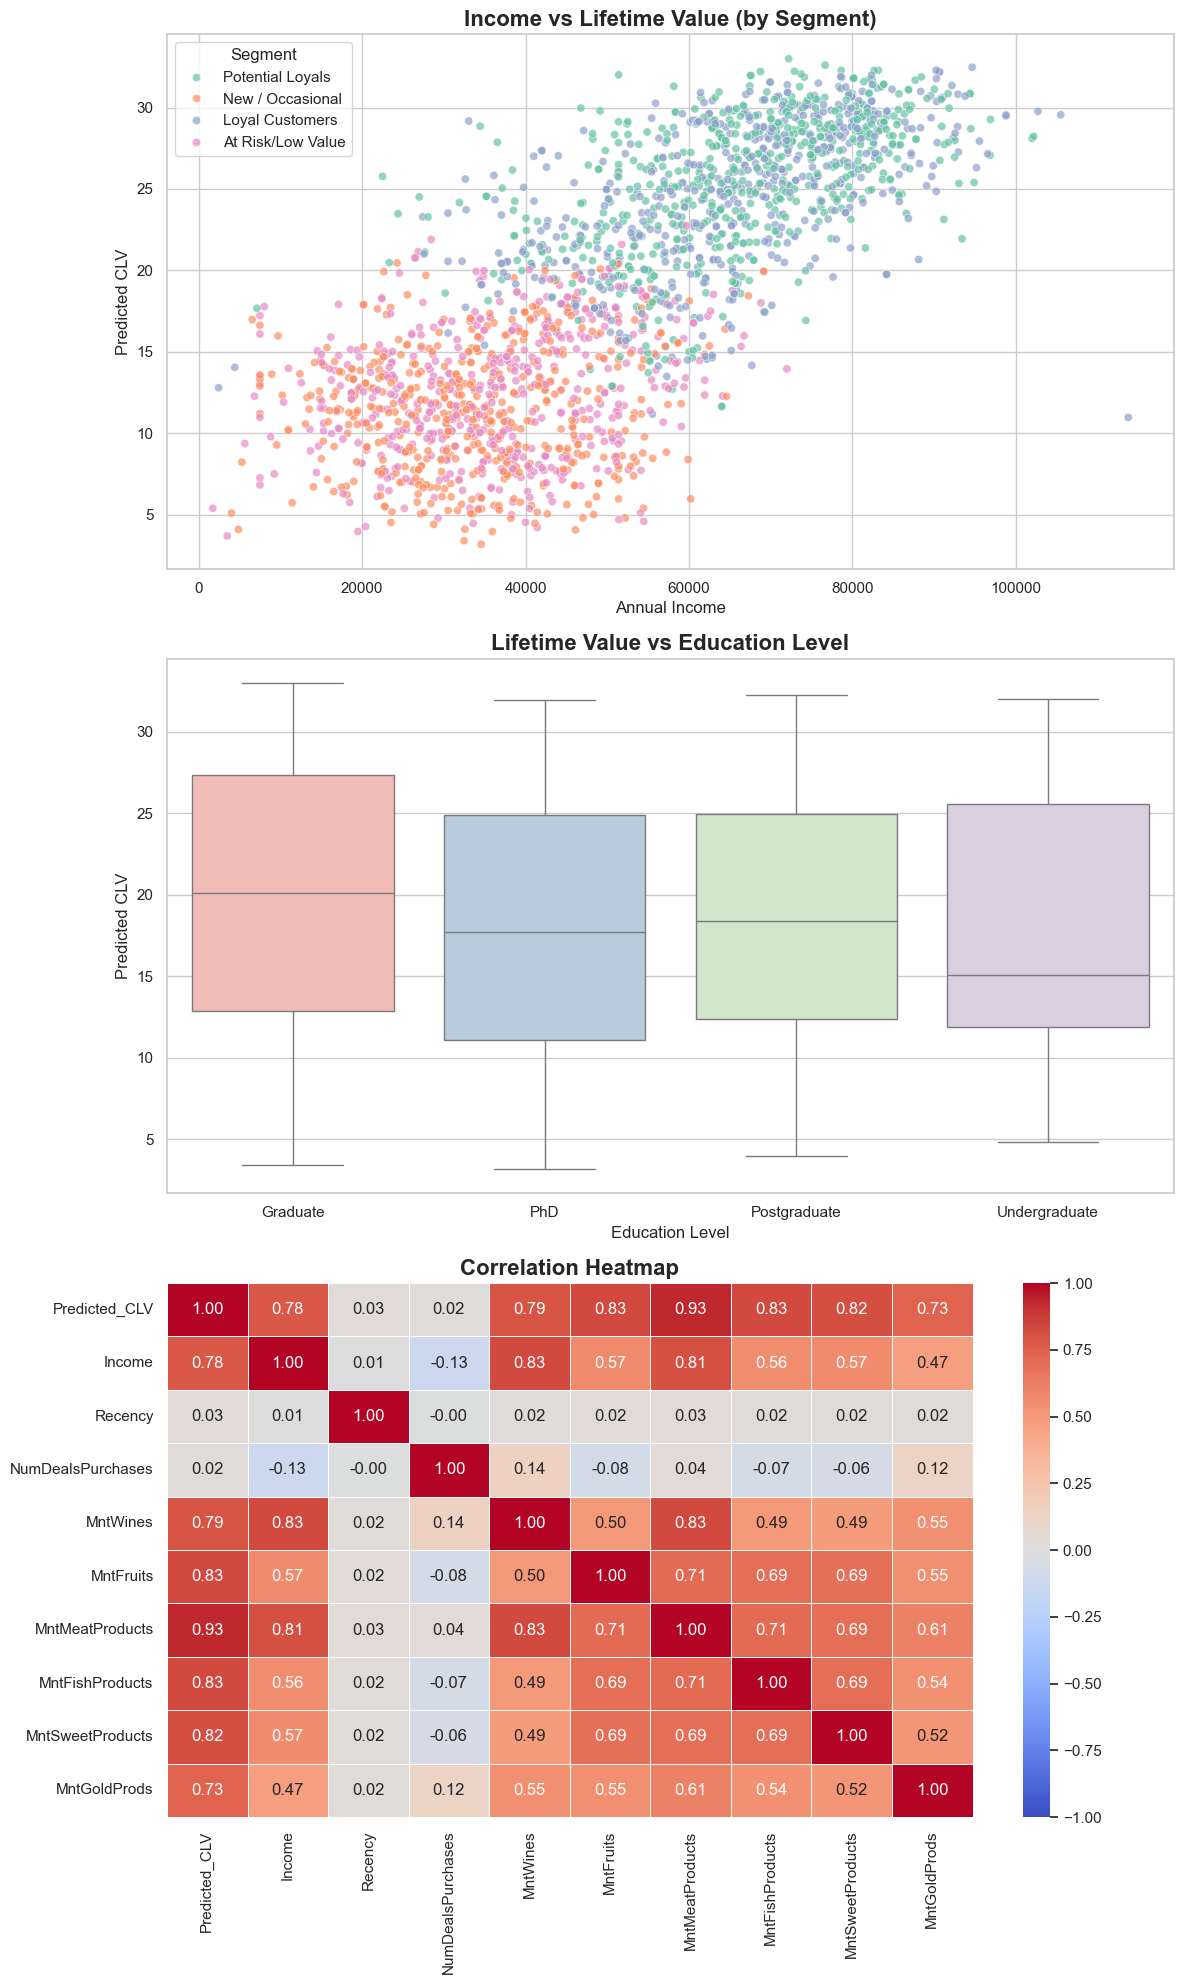

In [10]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 20))

# Income vs. Predicted CLV (Scatter Plot)
sns.scatterplot(
    ax=axes[0], 
    data = clv_df,
    x='Income', 
    y='Predicted_CLV', 
    hue='Segment', 
    palette='Set2', 
    alpha=0.7
)
axes[0].set_title('Income vs Lifetime Value (by Segment)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Annual Income', fontsize=12)
axes[0].set_ylabel('Predicted CLV', fontsize=12)

# Education Level vs. Predicted CLV (Box & Swarm Plot)
sns.boxplot(
    ax=axes[1], 
    data=clv_df, 
    x='Education', 
    y='Predicted_CLV', 
    palette='Pastel1',
    showfliers=True
)

axes[1].set_title('Lifetime Value vs Education Level', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Education Level', fontsize=12)
axes[1].set_ylabel('Predicted CLV', fontsize=12)

# Correlation Matrix Heatmap
# Select key numerical columns to see what correlates most with CLV
cols_for_corr = ['Predicted_CLV', 'Income', 'Recency', 'NumDealsPurchases'] 
# Add any specific product categories if they exist (e.g., 'MntWines', 'MntMeatProducts')
product_cols = [col for col in clv_df.columns if col.startswith('Mnt')]
#cols_for_corr.extend(product_cols[:4]) # Just grab the first 4 product cols to avoid clutter
cols_for_corr.extend(product_cols)

corr_matrix = clv_df[cols_for_corr].corr()

sns.heatmap(
    ax=axes[2], 
    data=corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)
axes[2].set_title('Correlation Heatmap', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()